# Confidence Intervals: Deterministic and Few-Shot Prompts

Two self-contained parts in this notebook:

- **Part 1 (Sections 1-6): deterministic prompts** -- the 6 prompting strategies that
  never use few-shot examples (no-def, default, task-def, question, cot, scale). No
  seed dimension exists for these; the only uncertainty is test-set sampling.
- **Part 2 (Sections 7+): few-shot prompts** -- the 5 shot-counts (3/6/9/12/15), now
  with 3 exemplar seeds each (42 original, 101, 202). Every bootstrap replicate here
  does two random things, not one: first pick a seed, then resample instances within
  it -- so these CIs are wider than Part 1's, since they're absorbing a real extra
  source of uncertainty (exemplar choice) that deterministic prompts don't have.

All 14 models, both parts.

## 1. Config + loading

In [57]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

BASE = "/Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper"
CLASSES = ["FAVOR", "AGAINST", "NONE"]

# The 6 prompts that never involve few-shot examples -- no seed dimension exists
# for any of these, so every run of them only ever has seed=42.
DETERMINISTIC_PROMPTS = [
    "default_no_label_definitions", "default", "task_definition",
    "task_definition_scale", "question", "cot",
]

DATASETS = ["semeval", "ezstance", "mtcsd"]

# Only seed 42 (the original results) has deterministic-prompt data -- the seed-101/202
# reruns only ever covered few-shot conditions, by design.
DATASET_DIRS = {
    "semeval": ["data_out/stance/semeval_results"],
    "ezstance": ["data_out/stance/ezstance_test"],
    "mtcsd": ["data_out/stance/mtcsd_test_results", "data_out/stance/mtcsd_test"],
}

SHORT_NAMES = {
    "Qwen/Qwen3-1.7B": "Qwen3-1.7B",
    "Qwen/Qwen3-4B": "Qwen3-4B",
    "Qwen/Qwen3-4B-Instruct-2507": "Qwen3-4B-IT",
    "Qwen/Qwen3-8B": "Qwen3-8B",
    "Qwen/Qwen3-14B": "Qwen3-14B",
    "deepseek-ai/DeepSeek-R1-Distill-Llama-8B": "DS-Llama-8B",
    "deepseek-ai/DeepSeek-R1-Distill-Qwen-14B": "DS-Qwen-14B",
    "meta-llama/Llama-3.1-8B-Instruct": "Llama-3.1-8B",
    "microsoft/phi-4": "Phi-4",
    "microsoft/phi-4-mini-instruct": "Phi-4-mini",
    "Nemotron-Mini-4B-Instruct": "Nemotron-4B",
    "nvidia/Nemotron-Mini-4B-Instruct": "Nemotron-4B",
    "gpt-5-mini": "GPT-5-mini",
    "gpt-5.2": "GPT-5.2",
    "claude-haiku-4-5-20251001": "Haiku-4.5",
}
MODELS = [
    "Qwen3-1.7B", "Qwen3-4B", "Qwen3-4B-IT", "Qwen3-8B", "Qwen3-14B",
    "DS-Llama-8B", "DS-Qwen-14B", "Llama-3.1-8B", "Phi-4", "Phi-4-mini",
    "Nemotron-4B", "GPT-5-mini", "GPT-5.2", "Haiku-4.5",
]


def normalize_label(x):
    if pd.isna(x):
        return None
    s = str(x).strip().upper()
    if s == "FAVOR":
        return "FAVOR"
    if s == "AGAINST":
        return "AGAINST"
    if s in ("NONE", "NEUTRAL", "NEITHER"):
        return "NONE"
    return None


In [58]:
def load_predictions(dataset):
    """Scan every run folder for this dataset, read model/prompt from summary.json
    (robust to folder-name quirks), keep deterministic-prompt rows only."""
    rows = []
    for rel_dir in DATASET_DIRS[dataset]:
        full_dir = os.path.join(BASE, rel_dir)
        if not os.path.isdir(full_dir):
            continue
        for folder in sorted(os.listdir(full_dir)):
            folder_path = os.path.join(full_dir, folder)
            summary_path = os.path.join(folder_path, "summary.json")
            assignments_path = os.path.join(folder_path, "document_assignments.csv")
            if not (os.path.isdir(folder_path) and os.path.exists(summary_path) and os.path.exists(assignments_path)):
                continue

            with open(summary_path) as f:
                s = json.load(f)
            cfg = s.get("configuration", {})
            backend = cfg.get("llm_backend", "")
            if backend == "vllm":
                model_raw = cfg.get("vllm_model", "")
            elif backend == "openai":
                model_raw = cfg.get("openai_model", "")
            elif backend == "claude":
                model_raw = cfg.get("claude_model", "")
            else:
                continue

            prompt = cfg.get("stance_prompt_name", "")
            if prompt not in DETERMINISTIC_PROMPTS:
                continue
            model = SHORT_NAMES.get(model_raw, model_raw.split("/")[-1])
            if model not in MODELS:
                continue

            df = pd.read_csv(assignments_path)
            if "run" in df.columns:
                df = df[df["run"] == 0]
            df["gold"] = df["original_stance"].apply(normalize_label)
            df["pred"] = df["predicted_stance"].apply(normalize_label)
            df["dataset"] = dataset
            df["model"] = model
            df["prompt"] = prompt
            rows.append(df[["dataset", "model", "prompt", "gold", "pred"]])

    if not rows:
        return pd.DataFrame(columns=["dataset", "model", "prompt", "gold", "pred"])
    return pd.concat(rows, ignore_index=True)


predictions = pd.concat([load_predictions(d) for d in DATASETS], ignore_index=True)
print(f"Loaded {len(predictions):,} prediction rows")
print(predictions.groupby("dataset").size())


Loaded 525,109 prediction rows
dataset
ezstance    221029
mtcsd       199164
semeval     104916
dtype: int64


## 2. Data-quality check

Same check as before -- flag any (dataset, model, prompt) cell where predictions mostly failed to parse, before trusting any score built from it.

In [59]:
validity = (
    predictions.assign(valid=lambda d: d["gold"].notna() & d["pred"].notna())
    .groupby(["dataset", "model", "prompt"])
    .agg(n_total=("valid", "size"), n_valid=("valid", "sum"))
    .reset_index()
)
validity["valid_rate"] = validity["n_valid"] / validity["n_total"]

bad = validity[validity["valid_rate"] < 0.95].sort_values("valid_rate")
print(f"{len(bad)} cells below 95% valid-prediction rate:")
if len(bad):
    display(bad)
else:
    print("  none -- data looks clean")

clean_keys = set(map(tuple, validity[validity["valid_rate"] >= 0.95][["dataset", "model", "prompt"]].values))


0 cells below 95% valid-prediction rate:
  none -- data looks clean


## 3. Point estimates

The actual, real (non-resampled) macro-F1 (F_avg for MT2-CSD) for each cell -- this is what Tables 2-4 report, and it's also what the dot in the final scatter plot is built from (never the average of the bootstrap resamples).

In [60]:
def macro_f1_arrays(gold, pred):
    return f1_score(gold, pred, labels=CLASSES, average=None, zero_division=0).mean()


def favg_arrays(gold, pred):
    f_favor = f1_score(gold, pred, labels=["FAVOR"], average="macro", zero_division=0)
    f_against = f1_score(gold, pred, labels=["AGAINST"], average="macro", zero_division=0)
    return (f_favor + f_against) / 2


def metric_for(dataset):
    return favg_arrays if dataset == "mtcsd" else macro_f1_arrays


def point_estimate(sub, dataset):
    valid = sub[sub["gold"].notna() & sub["pred"].notna()]
    if len(valid) < 10:
        return np.nan
    return metric_for(dataset)(valid["gold"].values, valid["pred"].values)


_rows = []
for (dataset, model, prompt), sub in predictions.groupby(["dataset", "model", "prompt"]):
    _rows.append({
        "dataset": dataset, "model": model, "prompt": prompt,
        "n": len(sub), "score": point_estimate(sub, dataset),
    })
point_estimates = pd.DataFrame(_rows)

print("Sanity check -- SemEval, task_definition_scale (should match Table 2 'Scale' column):")
display(
    point_estimates[
        (point_estimates["dataset"] == "semeval") & (point_estimates["prompt"] == "task_definition_scale")
    ].sort_values("score", ascending=False)
)


Sanity check -- SemEval, task_definition_scale (should match Table 2 'Scale' column):


,dataset,model,prompt,n,score
190,semeval,GPT-5.2,task_definition_scale,1249,0.769485
184,semeval,GPT-5-mini,task_definition_scale,1249,0.766650
196,semeval,Haiku-4.5,task_definition_scale,1249,0.766252
214,semeval,Phi-4,task_definition_scale,1249,0.717805
178,semeval,DS-Qwen-14B,task_definition_scale,1249,0.653023
232,semeval,Qwen3-14B,task_definition_scale,1249,0.637030
238,semeval,Qwen3-4B,task_definition_scale,1249,0.627779
250,semeval,Qwen3-8B,task_definition_scale,1249,0.618209
172,semeval,DS-Llama-8B,task_definition_scale,1249,0.593658
244,semeval,Qwen3-4B-IT,task_definition_scale,1249,0.560541


## 4. Bootstrap CI table (one row per dataset x model x prompt)

For **one specific cell** (e.g. "SemEval, GPT-5-mini, task_definition_scale"):

1. Take that cell's real predictions (gold label, predicted label) -- N pairs.
2. Resample N pairs from them *with replacement* (duplicates expected -- that's the point).
3. Compute macro-F1 on that resample. That's 1 of 1000 replicate scores.
4. Repeat 1000 times, sort the 1000 scores, take the values at the 2.5th and 97.5th
   percentile -- that's the 95% CI (`ci_lo`, `ci_hi`).
5. The reported point estimate is the *real* score from step 1's actual data, not an
   average of the 1000 resampled scores.

This is deliberately per-cell -- no averaging across the 6 prompts happens here. Use
this table to attach a "±" to one specific number already sitting in Tables 2-4.

In [61]:
RNG = np.random.default_rng(42)
N_BOOT = 1000
LABEL_TO_CODE = {"FAVOR": 0, "AGAINST": 1, "NONE": 2}
MACRO_F1_CODES = [0, 1, 2]
FAVG_CODES = [0, 1]  # FAVOR, AGAINST only (NONE excluded, matches Table 4)


def _encode(labels_array):
    return np.array([LABEL_TO_CODE[x] for x in labels_array], dtype=np.int8)


def _f1_bootstrap_vectorized(gold_codes, pred_codes, n_boot, rng, avg_over_codes):
    """All n_boot resamples computed via vectorized numpy ops (fast), not a Python
    loop calling sklearn per replicate (which is what made an earlier version of
    this notebook time out)."""
    n = len(gold_codes)
    idx = rng.integers(0, n, size=(n_boot, n))
    g = gold_codes[idx]
    p = pred_codes[idx]
    f1_sum = np.zeros(n_boot)
    for c in avg_over_codes:
        tp = np.sum((g == c) & (p == c), axis=1)
        fp = np.sum((g != c) & (p == c), axis=1)
        fn = np.sum((g == c) & (p != c), axis=1)
        denom = 2 * tp + fp + fn
        f1c = np.where(denom > 0, 2 * tp / np.maximum(denom, 1), 0.0)
        f1_sum += f1c
    return f1_sum / len(avg_over_codes)


def bootstrap_cell(dataset, model, prompt, n_boot=N_BOOT, rng=RNG):
    if (dataset, model, prompt) not in clean_keys:
        return np.nan, np.nan, np.nan
    sub = predictions[
        (predictions["dataset"] == dataset) & (predictions["model"] == model) & (predictions["prompt"] == prompt)
    ]
    sub = sub[sub["gold"].notna() & sub["pred"].notna()]
    if len(sub) < 10:
        return np.nan, np.nan, np.nan

    avg_codes = FAVG_CODES if dataset == "mtcsd" else MACRO_F1_CODES
    point = metric_for(dataset)(sub["gold"].values, sub["pred"].values)
    scores = _f1_bootstrap_vectorized(_encode(sub["gold"].values), _encode(sub["pred"].values), n_boot, rng, avg_codes)
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return point, lo, hi


_rows = []
for dataset in DATASETS:
    for model in MODELS:
        for prompt in DETERMINISTIC_PROMPTS:
            point, lo, hi = bootstrap_cell(dataset, model, prompt)
            if not np.isnan(point):
                _rows.append({
                    "dataset": dataset, "model": model, "prompt": prompt,
                    "point": point, "ci_lo": lo, "ci_hi": hi, "ci_width": hi - lo,
                })
per_cell_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/deterministic_per_cell_ci.csv")
per_cell_ci.to_csv(out_path, index=False)
print(f"Saved {len(per_cell_ci)} rows -> {out_path}")
display(per_cell_ci.sort_values(["dataset", "model", "prompt"]).head(12))


Saved 251 rows -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/deterministic_per_cell_ci.csv


,dataset,model,prompt,point,ci_lo,ci_hi,ci_width
119,ezstance,DS-Llama-8B,cot,0.568879,0.551420,0.585737,0.034317
115,ezstance,DS-Llama-8B,default,0.524666,0.505958,0.541984,0.036025
114,ezstance,DS-Llama-8B,default_no_label_definitions,0.540412,0.522321,0.559040,0.036719
118,ezstance,DS-Llama-8B,question,0.573429,0.555206,0.592196,0.036990
116,ezstance,DS-Llama-8B,task_definition,0.554563,0.533822,0.572969,0.039147
117,ezstance,DS-Llama-8B,task_definition_scale,0.559567,0.540162,0.578460,0.038298
125,ezstance,DS-Qwen-14B,cot,0.597449,0.577951,0.615928,0.037977
121,ezstance,DS-Qwen-14B,default,0.590796,0.572314,0.608790,0.036476
120,ezstance,DS-Qwen-14B,default_no_label_definitions,0.586940,0.568618,0.606105,0.037488
124,ezstance,DS-Qwen-14B,question,0.622753,0.603972,0.640232,0.036260


## 5. Bootstrap CI scatter plot (pooled across the 6 deterministic prompts)

One dot + one range **per model**, answering "how much could this model's *overall*
deterministic-prompt score wobble" rather than one specific prompt's score. For one
model on one dataset, one replicate works like this:

1. For **each of the 6 deterministic prompts separately**: resample its predictions
   with replacement, compute macro-F1. (Same step-by-step procedure as Section 4,
   just repeated once per prompt instead of picking only one.)
2. That gives 6 numbers for this replicate. **Average those 6 into 1 number.**
3. Repeat steps 1-2 a thousand times -> 1000 averaged numbers (not 6000).
4. Take the 2.5th/97.5th percentile of those 1000 averages -> the bar.
5. The dot = average of the 6 prompts' *real* scores (not resampled) -- same
   "compute the real number separately from the resampling" rule as everywhere else.

This has to be a *stratified* average (average-per-replicate, not pooling all 6000
raw resampled numbers together) -- otherwise prompt-to-prompt wording differences
would leak into what's supposed to be a pure statistical-uncertainty measure.

In [62]:
def bootstrap_overall_deterministic(dataset, model, n_boot=N_BOOT, rng=RNG, metric_override=None):
    # metric_override lets you force macro-F1 (3-class) for mtcsd even though its
    # default is F_avg (2-class, matching Table 4's baseline comparison).
    if metric_override is not None:
        avg_codes = metric_override
    else:
        avg_codes = FAVG_CODES if dataset == "mtcsd" else MACRO_F1_CODES
    prompt_arrays = {}
    for prompt in DETERMINISTIC_PROMPTS:
        if (dataset, model, prompt) not in clean_keys:
            continue
        sub = predictions[
            (predictions["dataset"] == dataset) & (predictions["model"] == model) & (predictions["prompt"] == prompt)
        ]
        sub = sub[sub["gold"].notna() & sub["pred"].notna()]
        if len(sub) >= 10:
            prompt_arrays[prompt] = (_encode(sub["gold"].values), _encode(sub["pred"].values))
    if not prompt_arrays:
        return np.nan, np.nan, np.nan, 0

        # (real, non-resampled) point estimate per prompt, then averaged
    inv_map = {v: k for k, v in LABEL_TO_CODE.items()}
    point_metric_fn = macro_f1_arrays if metric_override is not None else metric_for(dataset)
    point_vals = []
    replicate_scores_per_prompt = []
    for prompt, (gold_codes, pred_codes) in prompt_arrays.items():
        gold_labels = np.vectorize(inv_map.get)(gold_codes)
        pred_labels = np.vectorize(inv_map.get)(pred_codes)
        point_vals.append(point_metric_fn(gold_labels, pred_labels))
        replicate_scores_per_prompt.append(_f1_bootstrap_vectorized(gold_codes, pred_codes, n_boot, rng, avg_codes))
    point = float(np.mean(point_vals))

    replicate_means = np.mean(np.vstack(replicate_scores_per_prompt), axis=0)
    lo, hi = np.percentile(replicate_means, [2.5, 97.5])
    return point, lo, hi, len(prompt_arrays)


_rows = []
for dataset in DATASETS:
    for model in MODELS:
        point, lo, hi, n_prompts = bootstrap_overall_deterministic(dataset, model)
        _rows.append({
            "dataset": dataset, "model": model,
            "point": point, "ci_lo": lo, "ci_hi": hi, "n_prompts_available": n_prompts,
        })
overall_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/deterministic_overall_ci.csv")
overall_ci.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
display(overall_ci)


Saved -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/deterministic_overall_ci.csv


,dataset,model,point,ci_lo,ci_hi,n_prompts_available
0,semeval,Qwen3-1.7B,0.376372,0.364781,0.386800,6
1,semeval,Qwen3-4B,0.613341,0.601770,0.624181,6
2,semeval,Qwen3-4B-IT,0.602752,0.591447,0.613544,6
3,semeval,Qwen3-8B,0.583439,0.572946,0.594476,6
4,semeval,Qwen3-14B,0.599588,0.587790,0.610622,6
5,semeval,DS-Llama-8B,0.567195,0.555463,0.578428,6
6,semeval,DS-Qwen-14B,0.631358,0.619676,0.641624,6
7,semeval,Llama-3.1-8B,0.579996,0.567935,0.591537,6
8,semeval,Phi-4,0.653401,0.642881,0.664252,6
9,semeval,Phi-4-mini,0.565758,0.554730,0.576829,6


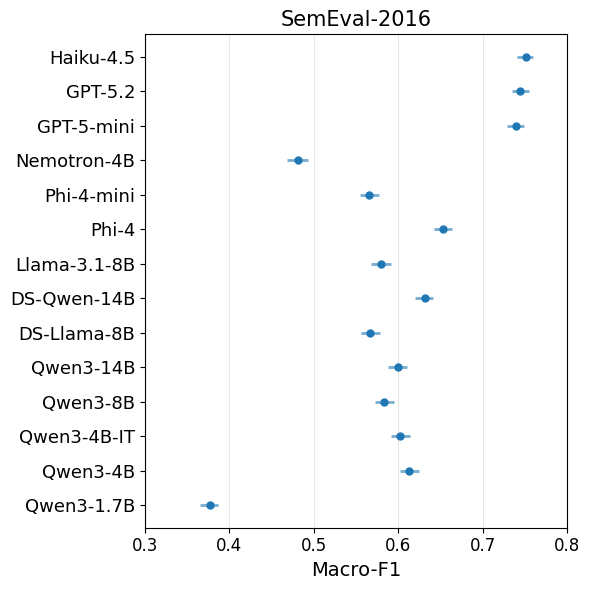

In [63]:
def plot_deterministic_ci(df, dataset, title, color, out_name, xlabel=None):
    sub = df[df["dataset"] == dataset].dropna(subset=["point"]) if "dataset" in df.columns else df
    sub = sub.set_index("model").reindex(MODELS).dropna(subset=["point"])  # fixed MODELS order, same across every chart

    fig, ax = plt.subplots(figsize=(6, 6))
    y = np.arange(len(sub))
    ax.hlines(y, sub["ci_lo"], sub["ci_hi"], color=color, alpha=0.6, linewidth=2)
    ax.scatter(sub["point"], y, color=color, s=25, zorder=3)
    ax.set_yticks(y)
    ax.set_yticklabels(sub.index, fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel(xlabel if xlabel is not None else ("Macro-F1" if dataset != "mtcsd" else "F_avg"), fontsize=14)
    ax.tick_params(axis="x", labelsize=12)
    ax.set_xlim(0.30, 0.80)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(BASE, f"data_out/stance/stance_analysis/{out_name}.png"), dpi=300, bbox_inches="tight")
    plt.show()


plot_deterministic_ci(overall_ci, "semeval", "SemEval-2016", "#1f77b4", "deterministic_ci_semeval", xlabel="Macro-F1")


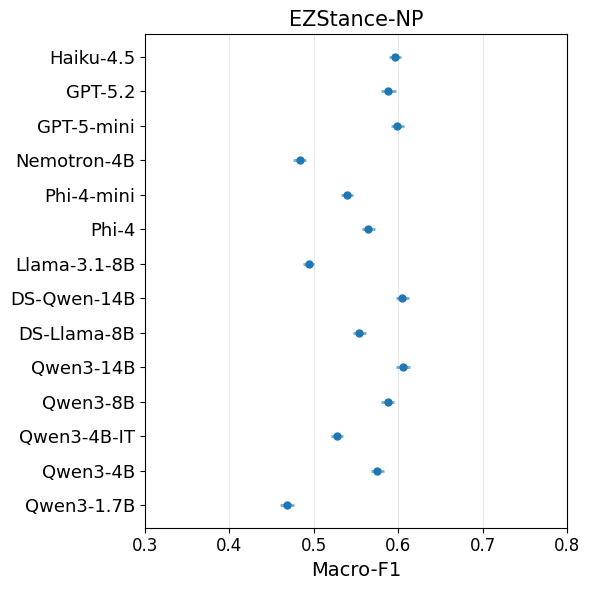

In [64]:
plot_deterministic_ci(overall_ci, "ezstance", "EZStance-NP", "#1f77b4", "deterministic_ci_ezstance", xlabel="Macro-F1")


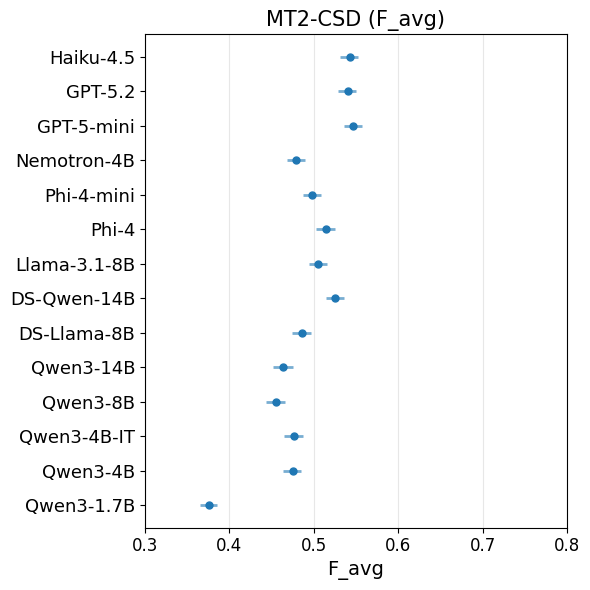

In [65]:
plot_deterministic_ci(overall_ci, "mtcsd", "MT2-CSD (F_avg)", "#1f77b4", "deterministic_ci_mtcsd_favg", xlabel="F_avg")


## 6. MTCSD: macro-F1 view (in addition to F_avg)

Table 4 reports MTCSD using F_avg (2-class, NONE excluded) because that's what the
KPT baseline supports -- but the paper notes 3-class macro-F1 is also computed for
MTCSD elsewhere. This recomputes the same pooled bootstrap CI as Section 5, just
forcing macro-F1 (all 3 classes) instead of F_avg for this one dataset, as its own
separate figure, alongside the existing F_avg one from Section 5.

In [66]:
_rows = []
for model in MODELS:
    point, lo, hi, n_prompts = bootstrap_overall_deterministic("mtcsd", model, metric_override=MACRO_F1_CODES)
    _rows.append({"model": model, "point": point, "ci_lo": lo, "ci_hi": hi, "n_prompts_available": n_prompts})
mtcsd_macro_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/deterministic_mtcsd_macro_f1_ci.csv")
mtcsd_macro_ci.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
display(mtcsd_macro_ci)


Saved -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/deterministic_mtcsd_macro_f1_ci.csv


,model,point,ci_lo,ci_hi,n_prompts_available
0,Qwen3-1.7B,0.458881,0.450320,0.467782,6
1,Qwen3-4B,0.532697,0.523142,0.540817,6
2,Qwen3-4B-IT,0.536667,0.527487,0.545540,6
3,Qwen3-8B,0.531229,0.522254,0.540431,6
4,Qwen3-14B,0.541580,0.532086,0.551404,6
5,DS-Llama-8B,0.536345,0.527122,0.545092,6
6,DS-Qwen-14B,0.573259,0.564260,0.582866,6
7,Llama-3.1-8B,0.491949,0.483251,0.500087,6
8,Phi-4,0.560768,0.552053,0.569196,6
9,Phi-4-mini,0.525616,0.517177,0.533637,6


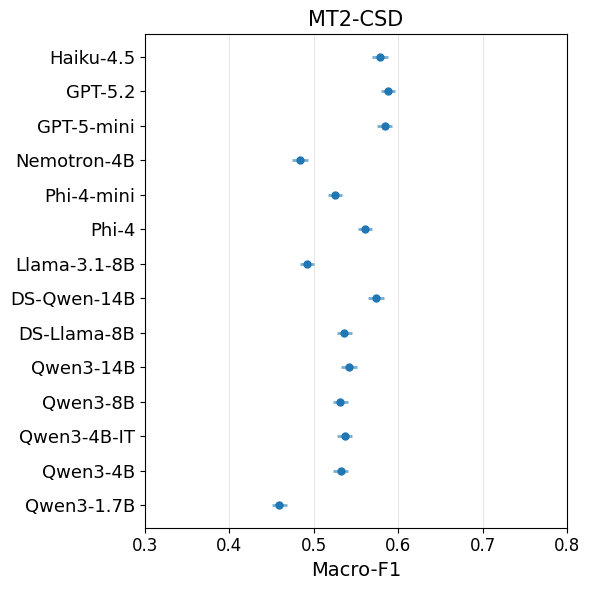

In [67]:
plot_deterministic_ci(mtcsd_macro_ci, "mtcsd", "MT2-CSD", "#1f77b4", "deterministic_ci_mtcsd_macrof1", xlabel="Macro-F1")


## 7. Few-shot: config + loading

Same models, same 3 datasets, but now the 5 few-shot prompts (3/6/9/12/15-shot)
across all 3 seeds. Reuses `MODELS`, `SHORT_NAMES`, `CLASSES`, `LABEL_TO_CODE`, and
the bootstrap primitives already defined in Part 1 -- only the loading and the
seed-aware resampling logic are new.

In [48]:
FEWSHOT_PROMPTS = ["few_shot_3", "few_shot_6", "few_shot_9", "few_shot_12", "few_shot_15"]
SEEDS = [42, 101, 202]

# Seed 42 = original results (single seed, same folders as Part 1's DATASET_DIRS).
# Seeds 101/202 = new exemplar-seed reruns -- these only ever cover few-shot conditions.
FEWSHOT_DATASET_DIRS_BY_SEED = {
    42: DATASET_DIRS,
    101: {
        "semeval": ["data_out/few_shot_seed101/semeval2016_task6_testdata_gold"],
        "ezstance": ["data_out/few_shot_seed101/ezstance_test"],
        "mtcsd": ["data_out/few_shot_seed101/mtcsd_test"],
    },
    202: {
        "semeval": ["data_out/few_shot_seed202/semeval2016_task6_testdata_gold"],
        "ezstance": ["data_out/few_shot_seed202/ezstance_test"],
        "mtcsd": ["data_out/few_shot_seed202/mtcsd_test"],
    },
}


def load_fewshot_predictions(seed, dataset):
    rows = []
    for rel_dir in FEWSHOT_DATASET_DIRS_BY_SEED[seed][dataset]:
        full_dir = os.path.join(BASE, rel_dir)
        if not os.path.isdir(full_dir):
            continue
        for folder in sorted(os.listdir(full_dir)):
            folder_path = os.path.join(full_dir, folder)
            summary_path = os.path.join(folder_path, "summary.json")
            assignments_path = os.path.join(folder_path, "document_assignments.csv")
            if not (os.path.isdir(folder_path) and os.path.exists(summary_path) and os.path.exists(assignments_path)):
                continue
            cfg = json.load(open(summary_path)).get("configuration", {})
            backend = cfg.get("llm_backend", "")
            if backend == "vllm":
                model_raw = cfg.get("vllm_model", "")
            elif backend == "openai":
                model_raw = cfg.get("openai_model", "")
            elif backend == "claude":
                model_raw = cfg.get("claude_model", "")
            else:
                continue
            prompt = cfg.get("stance_prompt_name", "")
            if prompt not in FEWSHOT_PROMPTS:
                continue
            model = SHORT_NAMES.get(model_raw, model_raw.split("/")[-1])
            if model not in MODELS:
                continue
            df = pd.read_csv(assignments_path)
            if "run" in df.columns:
                df = df[df["run"] == 0]
            df["gold"] = df["original_stance"].apply(normalize_label)
            df["pred"] = df["predicted_stance"].apply(normalize_label)
            df["dataset"] = dataset
            df["model"] = model
            df["prompt"] = prompt
            df["seed"] = seed
            rows.append(df[["dataset", "model", "prompt", "seed", "gold", "pred"]])
    if not rows:
        return pd.DataFrame(columns=["dataset", "model", "prompt", "seed", "gold", "pred"])
    return pd.concat(rows, ignore_index=True)


fewshot_predictions = pd.concat(
    [load_fewshot_predictions(s, d) for s in SEEDS for d in DATASETS], ignore_index=True
)
print(f"Loaded {len(fewshot_predictions):,} few-shot prediction rows")
print(fewshot_predictions.groupby(["dataset", "seed"]).size().unstack(fill_value=0))


Loaded 1,319,430 few-shot prediction rows
seed         42      101     202
dataset                         
ezstance  186410  186410  186410
mtcsd     165970  165970  165970
semeval    87430   87430   87430


## 8. Few-shot data-quality check

Same 95%-valid-prediction-rate rule as Part 1. GPT-5-mini/GPT-5.2 have a known intermittent parsing issue on some few-shot cells (see the flagged rows below) -- these are automatically excluded from every table and chart in this section, not silently averaged in.

In [49]:
fewshot_validity = (
    fewshot_predictions.assign(valid=lambda d: d["gold"].notna() & d["pred"].notna())
    .groupby(["dataset", "model", "prompt", "seed"])
    .agg(n_total=("valid", "size"), n_valid=("valid", "sum"))
    .reset_index()
)
fewshot_validity["valid_rate"] = fewshot_validity["n_valid"] / fewshot_validity["n_total"]

fewshot_bad = fewshot_validity[fewshot_validity["valid_rate"] < 0.95].sort_values("valid_rate")
print(f"{len(fewshot_bad)} / {len(fewshot_validity)} cells excluded (below 95% valid-prediction rate):")
if len(fewshot_bad):
    display(fewshot_bad)

fewshot_clean_keys = set(map(
    tuple, fewshot_validity[fewshot_validity["valid_rate"] >= 0.95][["dataset", "model", "prompt", "seed"]].values
))


10 / 630 cells excluded (below 95% valid-prediction rate):


,dataset,model,prompt,seed,n_total,n_valid,valid_rate
34,ezstance,GPT-5-mini,few_shot_15,101,2663,1330,0.499437
454,semeval,GPT-5-mini,few_shot_15,101,1249,630,0.504404
472,semeval,GPT-5.2,few_shot_3,101,1249,638,0.510809
463,semeval,GPT-5-mini,few_shot_9,101,1249,776,0.621297
52,ezstance,GPT-5.2,few_shot_3,101,2663,2129,0.799474
460,semeval,GPT-5-mini,few_shot_6,101,1249,1002,0.802242
451,semeval,GPT-5-mini,few_shot_12,101,1249,1032,0.826261
55,ezstance,GPT-5.2,few_shot_6,101,2663,2367,0.888847
459,semeval,GPT-5-mini,few_shot_6,42,1249,1175,0.940753
453,semeval,GPT-5-mini,few_shot_15,42,1249,1182,0.946357


## 9. Bootstrap CI table (one row per dataset x model x shot-count)

For one cell (e.g. "SemEval, Qwen3-4B, 9-shot"), each of the 1000 replicates does
**two** random things instead of one: first randomly pick one of the available clean
seeds (42/101/202), *then* resample instances with replacement within that seed's
predictions. This is what makes a few-shot CI capture exemplar-choice uncertainty on
top of test-set sampling uncertainty -- the extra step Part 1's deterministic prompts
don't have.

The dot (point estimate) = the average of each available seed's real, non-resampled
score -- e.g. if all 3 seeds are clean, that's (score_42 + score_101 + score_202) / 3.
This matches Reviewer 1's literal "average +/- CI" request, and is why it differs
slightly from the single-seed numbers already in Tables 2-4.

In [50]:
def _fewshot_seed_arrays(dataset, model, prompt):
    out = {}
    for s in SEEDS:
        if (dataset, model, prompt, s) not in fewshot_clean_keys:
            continue
        sub = fewshot_predictions[
            (fewshot_predictions["dataset"] == dataset) & (fewshot_predictions["model"] == model)
            & (fewshot_predictions["prompt"] == prompt) & (fewshot_predictions["seed"] == s)
        ]
        sub = sub[sub["gold"].notna() & sub["pred"].notna()]
        if len(sub) > 0:
            out[s] = (_encode(sub["gold"].values), _encode(sub["pred"].values))
    return out


def bootstrap_cell_fewshot(dataset, model, prompt, n_boot=N_BOOT, rng=RNG):
    seed_data = _fewshot_seed_arrays(dataset, model, prompt)
    if not seed_data:
        return np.nan, np.nan, np.nan, 0
    avg_codes = FAVG_CODES if dataset == "mtcsd" else MACRO_F1_CODES
    inv_map = {v: k for k, v in LABEL_TO_CODE.items()}
    # Point = average of each available seed's REAL (non-resampled) score -- matches
    # Reviewer 1's literal "average +/- CI" request, not just seed 42's single run.
    metric_fn = metric_for(dataset)
    point_vals = [
        metric_fn(np.vectorize(inv_map.get)(g), np.vectorize(inv_map.get)(p))
        for g, p in seed_data.values()
    ]
    point = float(np.mean(point_vals))

    available = list(seed_data.keys())
    draws = rng.integers(0, len(available), size=n_boot)
    scores = np.empty(n_boot)
    for si, s in enumerate(available):
        mask = draws == si
        k = int(mask.sum())
        if k == 0:
            continue
        gold, pred = seed_data[s]
        scores[mask] = _f1_bootstrap_vectorized(gold, pred, k, rng, avg_codes)
    lo, hi = np.percentile(scores, [2.5, 97.5])
    return point, lo, hi, len(available)


_rows = []
for dataset in DATASETS:
    for model in MODELS:
        for prompt in FEWSHOT_PROMPTS:
            point, lo, hi, n_seeds = bootstrap_cell_fewshot(dataset, model, prompt)
            if not np.isnan(point):
                _rows.append({"dataset": dataset, "model": model, "prompt": prompt,
                              "point": point, "ci_lo": lo, "ci_hi": hi, "n_seeds": n_seeds})
fewshot_per_cell_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/fewshot_per_cell_ci.csv")
fewshot_per_cell_ci.to_csv(out_path, index=False)
print(f"Saved {len(fewshot_per_cell_ci)} rows -> {out_path}")
display(fewshot_per_cell_ci.head(10))


Saved 210 rows -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/fewshot_per_cell_ci.csv


,dataset,model,prompt,point,ci_lo,ci_hi,n_seeds
0,semeval,Qwen3-1.7B,few_shot_3,0.346220,0.290978,0.400374,3
1,semeval,Qwen3-1.7B,few_shot_6,0.355635,0.304262,0.413860,3
2,semeval,Qwen3-1.7B,few_shot_9,0.364829,0.302981,0.418948,3
3,semeval,Qwen3-1.7B,few_shot_12,0.366510,0.312739,0.443709,3
4,semeval,Qwen3-1.7B,few_shot_15,0.393650,0.357481,0.426557,3
5,semeval,Qwen3-4B,few_shot_3,0.592149,0.522972,0.676240,3
6,semeval,Qwen3-4B,few_shot_6,0.619200,0.568355,0.677304,3
7,semeval,Qwen3-4B,few_shot_9,0.613941,0.569313,0.667345,3
8,semeval,Qwen3-4B,few_shot_12,0.612281,0.549251,0.690935,3
9,semeval,Qwen3-4B,few_shot_15,0.621193,0.581753,0.663512,3


## 10. Bootstrap CI scatter plots (pooled across the 5 few-shot conditions)

One dot + 95% CI per model, per dataset -- same stratified-averaging rule as Part
1's Section 5 (each replicate resamples all 5 shot-counts independently, seed-drawing
each one, then averages the 5 into 1 number), just applied to the 5 few-shot prompts
instead of the 6 deterministic ones. Separate figure per dataset, same color as every
other chart in this notebook. The dot is likewise
an average of real per-seed scores (per prompt, then averaged again across the 5
prompts) -- never a value read off a single seed.

In [51]:
def bootstrap_overall_fewshot(dataset, model, n_boot=N_BOOT, rng=RNG, metric_override=None):
    # metric_override lets mtcsd be forced to macro-F1 (3-class) even though its
    # default is F_avg (2-class) -- same pattern as bootstrap_overall_deterministic.
    if metric_override is not None:
        avg_codes = metric_override
    else:
        avg_codes = FAVG_CODES if dataset == "mtcsd" else MACRO_F1_CODES
    inv_map = {v: k for k, v in LABEL_TO_CODE.items()}
    prompt_seed_data = {p: _fewshot_seed_arrays(dataset, model, p) for p in FEWSHOT_PROMPTS}
    prompt_seed_data = {p: sd for p, sd in prompt_seed_data.items() if sd}
    if not prompt_seed_data:
        return np.nan, np.nan, np.nan, 0

    point_metric_fn = macro_f1_arrays if metric_override is not None else metric_for(dataset)
    point_vals = []
    replicate_scores_per_prompt = []
    for prompt, sd in prompt_seed_data.items():
        # Average over each available seed's REAL score first (per-prompt average,
        # same rule as bootstrap_cell_fewshot), then this gets averaged again across
        # the 5 prompts below -- consistent two-level averaging, not seed-42-only.
        seed_point_vals = [
            point_metric_fn(np.vectorize(inv_map.get)(g), np.vectorize(inv_map.get)(p))
            for g, p in sd.values()
        ]
        point_vals.append(float(np.mean(seed_point_vals)))

        available = list(sd.keys())
        draws = rng.integers(0, len(available), size=n_boot)
        scores = np.empty(n_boot)
        for si, s in enumerate(available):
            mask = draws == si
            k = int(mask.sum())
            if k == 0:
                continue
            gold, pred = sd[s]
            scores[mask] = _f1_bootstrap_vectorized(gold, pred, k, rng, avg_codes)
        replicate_scores_per_prompt.append(scores)

    point = float(np.mean(point_vals))
    replicate_means = np.mean(np.vstack(replicate_scores_per_prompt), axis=0)
    lo, hi = np.percentile(replicate_means, [2.5, 97.5])
    return point, lo, hi, len(prompt_seed_data)


_rows = []
for dataset in DATASETS:
    for model in MODELS:
        point, lo, hi, n_prompts = bootstrap_overall_fewshot(dataset, model)
        _rows.append({"dataset": dataset, "model": model, "point": point, "ci_lo": lo, "ci_hi": hi,
                      "n_prompts_available": n_prompts})
fewshot_overall_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/fewshot_overall_ci.csv")
fewshot_overall_ci.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
display(fewshot_overall_ci)


Saved -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/fewshot_overall_ci.csv


,dataset,model,point,ci_lo,ci_hi,n_prompts_available
0,semeval,Qwen3-1.7B,0.365369,0.335617,0.394742,5
1,semeval,Qwen3-4B,0.611753,0.581025,0.646769,5
2,semeval,Qwen3-4B-IT,0.658811,0.642946,0.673543,5
3,semeval,Qwen3-8B,0.643650,0.618725,0.672001,5
4,semeval,Qwen3-14B,0.615461,0.590761,0.642716,5
5,semeval,DS-Llama-8B,0.548144,0.531673,0.564014,5
6,semeval,DS-Qwen-14B,0.638025,0.623461,0.652255,5
7,semeval,Llama-3.1-8B,0.560376,0.534037,0.585048,5
8,semeval,Phi-4,0.691371,0.676114,0.706498,5
9,semeval,Phi-4-mini,0.578273,0.560548,0.595665,5


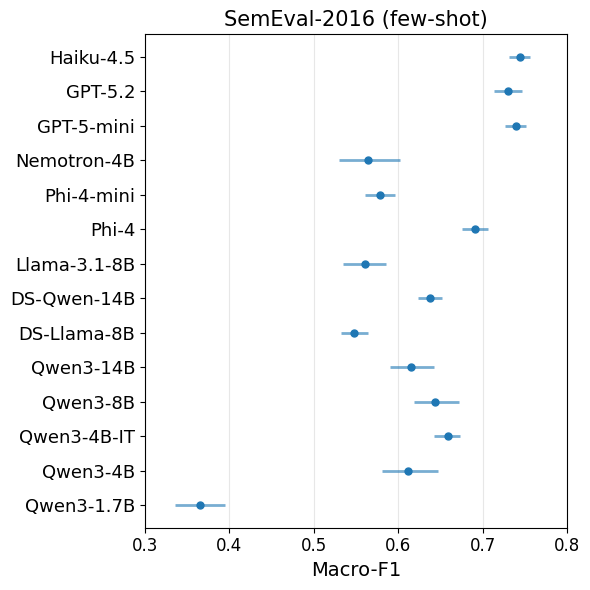

In [52]:
plot_deterministic_ci(fewshot_overall_ci, "semeval", "SemEval-2016 (few-shot)", "#1f77b4", "fewshot_ci_semeval", xlabel="Macro-F1")


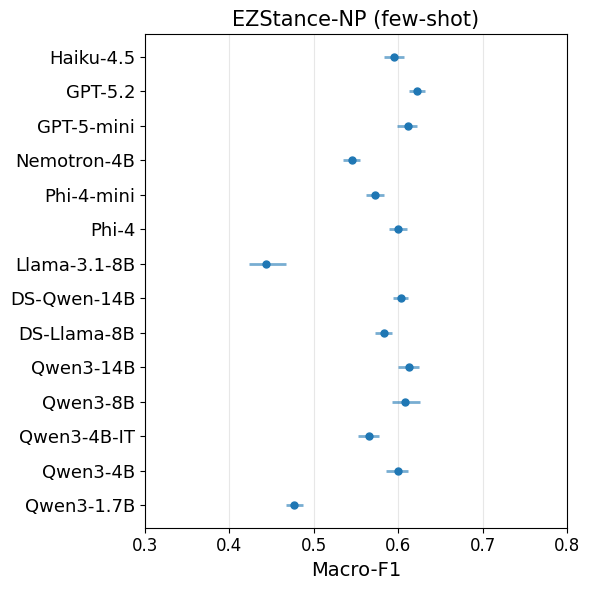

In [53]:
plot_deterministic_ci(fewshot_overall_ci, "ezstance", "EZStance-NP (few-shot)", "#1f77b4", "fewshot_ci_ezstance", xlabel="Macro-F1")


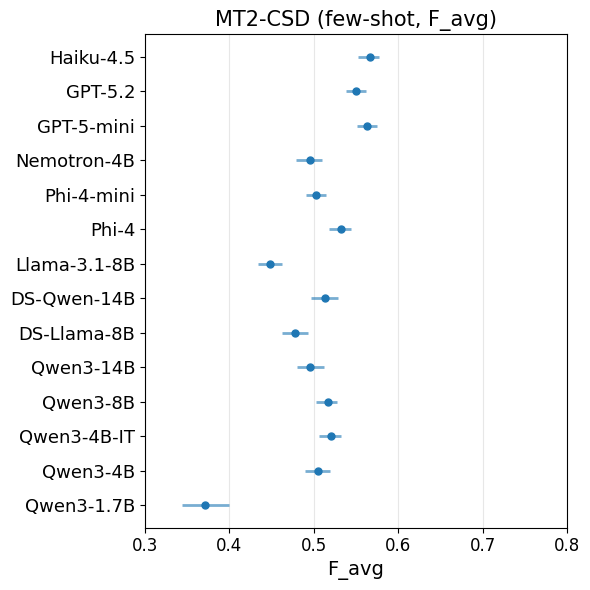

In [54]:
plot_deterministic_ci(fewshot_overall_ci, "mtcsd", "MT2-CSD (few-shot, F_avg)", "#1f77b4", "fewshot_ci_mtcsd", xlabel="F_avg")


## 11. MTCSD few-shot: macro-F1 view (in addition to F_avg)

Same reason as Part 1's Section 6 -- Table 4 reports MTCSD as F_avg (2-class), but
3-class macro-F1 is computed too. This forces `bootstrap_overall_fewshot` to use
macro-F1 instead of F_avg for this one dataset, with the same seed-draw +
instance-resample procedure as the rest of Part 2.

In [55]:
_rows = []
for model in MODELS:
    point, lo, hi, n_prompts = bootstrap_overall_fewshot("mtcsd", model, metric_override=MACRO_F1_CODES)
    _rows.append({"dataset": "mtcsd", "model": model, "point": point, "ci_lo": lo, "ci_hi": hi,
                  "n_prompts_available": n_prompts})
fewshot_mtcsd_macro_ci = pd.DataFrame(_rows)
out_path = os.path.join(BASE, "data_out/stance/stance_analysis/fewshot_mtcsd_macro_f1_ci.csv")
fewshot_mtcsd_macro_ci.to_csv(out_path, index=False)
print(f"Saved -> {out_path}")
display(fewshot_mtcsd_macro_ci)


Saved -> /Users/nityaakalra/Desktop/nyt_topic_modeling/topic_modeling_paper/data_out/stance/stance_analysis/fewshot_mtcsd_macro_f1_ci.csv


,dataset,model,point,ci_lo,ci_hi,n_prompts_available
0,mtcsd,Qwen3-1.7B,0.475058,0.456273,0.492934,5
1,mtcsd,Qwen3-4B,0.552408,0.540695,0.563843,5
2,mtcsd,Qwen3-4B-IT,0.551147,0.540614,0.561835,5
3,mtcsd,Qwen3-8B,0.559196,0.547946,0.570511,5
4,mtcsd,Qwen3-14B,0.560711,0.549529,0.572757,5
5,mtcsd,DS-Llama-8B,0.542631,0.530270,0.554981,5
6,mtcsd,DS-Qwen-14B,0.572560,0.560769,0.583964,5
7,mtcsd,Llama-3.1-8B,0.400695,0.379238,0.423339,5
8,mtcsd,Phi-4,0.577772,0.566693,0.587832,5
9,mtcsd,Phi-4-mini,0.509076,0.497827,0.519541,5


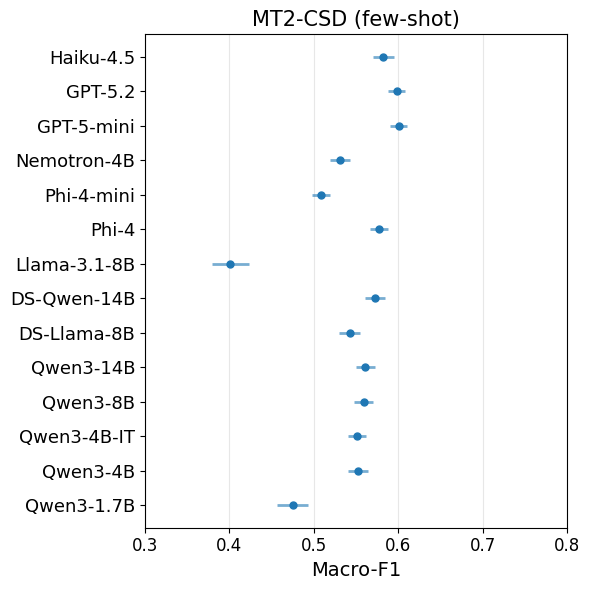

In [68]:
plot_deterministic_ci(fewshot_mtcsd_macro_ci, "mtcsd", "MT2-CSD (few-shot)", "#1f77b4", "fewshot_ci_mtcsd_macrof1", xlabel="Macro-F1")
